# **Hourly Origin-Destination Ridership: Komuter**

PlantPredictor


1. Chong Xiao Qing (24004482)

2. Kelly Goh Hui Shinn (24004576)

3. Khor Chek Lin (24004501)

4. Lee Zi Xuan (24004489)

5. Ng Rou Rou (23116745)

🎯Objective: To develop a **regression model for forecasting the number of train boardings at individual stations for the next hour**, using historical ridership data, time-based features, and external factors like holidays and rush hours.

🧠Model candidates: Exploring various tree-based and boosting regression models, leveraging engineered features.


📈Evaluation: Evaluating the performance of the models on a hold-out test set representing a future time period, using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

## **1.0 Dataset Collection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from bs4 import BeautifulSoup
from geopy.geocoders import Nominatim

import pandas as pd
import requests
import os
import csv
import time

Mounted at /content/drive


**1.1 Komuter Ridership Dataset**

Loading the main ridership data from a CSV file located in Google Drive




In [ ]:
# Import the komuter ridership dataset
komuter = pd.read_csv('/content/drive/MyDrive/komuter_2025.csv')
display(komuter)

,date,time,origin,destination,ridership
0,2025-01-01,00:00,Abdullah Hukum,Klang,1
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1
2,2025-01-01,00:00,Bangi,Batu Caves,1
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1
...,...,...,...,...,...
782746,2025-05-11,23:00,Sungai Buloh,Senawang,1
782747,2025-05-11,23:00,Sungai Buloh,Serendah,1
782748,2025-05-11,23:00,Tiroi,KL Sentral,1
782749,2025-05-11,23:00,UKM,Sentul,1


**1.2 Public Holiday Dataset**


Web scraping the additional public holiday data using BeautifulSoup

In [ ]:
# Request to a Malaysia public holiday (2025) webpage
url = "https://calendarmalaysia.com/public-holidays-2025/#google_vignette"
response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table")

# Extract data from the HTML table
headers = [th.get_text(strip=True) for th in table.find_all("th")]
rows = []

for tr in table.find("tbody").find_all("tr"):
    cells = [td.get_text(strip=True) for td in tr.find_all("td")]
    rows.append(cells)

# Convert extrated data into a DataFrame
holiday = pd.DataFrame(rows, columns=headers)
holiday.head()

,Date,Day,Holiday,States
0,01 Jan,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis..."
1,14 Jan,Tue,YDPB Negeri Sembilan's Birthday,Negeri Sembilan
2,27 Jan,Mon,Israk and Mikraj,"Kedah, Negeri Sembilan, Perlis & Terengganu"
3,29 Jan,Wed,Chinese New Year,National
4,30 Jan,Thu,Chinese New Year Holiday,National


In [ ]:
# Rename columns name
komuter.rename(columns={'date':'Date','time':'Time','origin':'Origin','destination':'Destination','ridership':'Ridership'}, inplace=True)
holiday.rename(columns={'States':'State'}, inplace=True)

**1.3 Merging Komuter Ridership and Public Holiday Datasets**

In [ ]:
komuter['Origin'].unique()

array(['Abdullah Hukum', 'Bangi', 'Bank Negara', 'Batu Tiga',
       'Bandar Tasek Selatan', 'Jalan Templer', 'Kajang', 'Kampung Batu',
       'KL Sentral', 'Klang', 'Kuala Lumpur', 'Nilai', 'Midvalley',
       'Petaling', 'Pulau Sebang (Tampin)', 'Rawang', 'Serdang',
       'Setia Jaya', 'Subang Jaya', 'Sungai Buloh', 'Tanjong Malim',
       'Batu Caves', 'Seremban', 'Shah Alam', 'UKM', 'Sentul',
       'Padang Jawa', 'Pelabuhan Klang Selatan', 'Sungai Gadut',
       'Telok Gadong', 'Telok Pulai', 'Tiroi', 'Unknown', 'Batang Benar',
       'Batang Kali', 'Bukit Badak', 'Jalan Kastam', 'Kajang 2', 'Kepong',
       'Kepong Sentral', 'Kampung Dato Harun', 'Kampung Raja Uda',
       'Kuala Kubu Bharu', 'Kuang', 'Labu', 'Pantai Dalam', 'Putra',
       'Rasa', 'Rembau', 'Salak Selatan', 'Segambut', 'Senawang',
       'Seputeh', 'Serendah', 'Seri Setia', 'Taman Wahyu', 'Angkasapuri',
       'Batu Kentonmen'], dtype=object)

In [ ]:
# Fix typo
komuter['Origin'] = komuter['Origin'].replace('Bandar Tasek Selatan', 'Bandar Tasik Selatan')

# Dictionary mapping each origin to its corresponding state
state = {
    'Abdullah Hukum':'Kuala Lumpur',
    'Bangi':'Selangor',
    'Bank Negara':'Kuala Lumpur',
    'Batu Tiga':'Selangor',
    'Bandar Tasik Selatan':'Kuala Lumpur',
    'Jalan Templer':'Selangor',
    'Kajang':'Selangor',
    'Kampung Batu':'Kuala Lumpur',
    'KL Sentral':'Kuala Lumpur',
    'Klang':'Selangor',
    'Kuala Lumpur':'Kuala Lumpur',
    'Nilai':'Negeri Sembilan',
    'Midvalley':'Kuala Lumpur',
    'Petaling':'Selangor',
    'Pulau Sebang (Tampin)':'Malacca',
    'Rawang':'Selangor',
    'Serdang':'Selangor',
    'Setia Jaya':'Selangor',
    'Subang Jaya':'Selangor',
    'Sungai Buloh':'Selangor',
    'Tanjong Malim':'Perak',
    'Batu Caves':'Selangor',
    'Seremban':'Negeri Sembilan',
    'Shah Alam':'Selangor',
    'UKM':'Selangor',
    'Sentul':'Kuala Lumpur',
    'Padang Jawa':'Selangor',
    'Pelabuhan Klang Selatan':'Selangor',
    'Sungai Gadut':'Negeri Sembilan',
    'Telok Gadong':'Selangor',
    'Telok Pulai':'Selangor',
    'Tiroi':'Negeri Sembilan',
    'Unknown':'Unknown',
    'Batang Benar':'Negeri Sembilan',
    'Batang Kali':'Selangor',
    'Bukit Badak':'Selangor',
    'Jalan Kastam':'Selangor',
    'Kajang 2':'Selangor',
    'Kepong':'Kuala Lumpur',
    'Kepong Sentral':'Kuala Lumpur',
    'Kampung Dato Harun':'Selangor',
    'Kampung Raja Uda':'Selangor',
    'Kuala Kubu Bharu':'Selangor',
    'Kuang':'Selangor',
    'Labu':'Negeri Sembilan',
    'Pantai Dalam':'Kuala Lumpur',
    'Putra':'Selangor',
    'Rasa':'Selangor',
    'Rembau':'Negeri Sembilan',
    'Salak Selatan':'Kuala Lumpur',
    'Segambut':'Kuala Lumpur',
    'Senawang':'Negeri Sembilan',
    'Seputeh':'Kuala Lumpur',
    'Serendah':'Selangor',
    'Seri Setia':'Selangor',
    'Taman Wahyu':'Kuala Lumpur',
    'Angkasapuri':'Kuala Lumpur',
    'Batu Kentonmen':'Kuala Lumpur'
}
komuter['State'] = komuter['Origin'].map(state)

Create new **Is Holiday** feature by intrepting the extracted public holiday data (Boolean: True if is holiday, else False)

In [ ]:
# Convert data columns to datatime format
komuter['Date'] = pd.to_datetime(komuter['Date'])
holiday['Date'] = holiday['Date'].astype(str) + ' 2025'
holiday['Date'] = pd.to_datetime(holiday['Date'], format='%d %b %Y')

# Merge komuter ridership and holiday data on date
df = pd.merge(komuter, holiday, on='Date', how='left')
df['Holiday_State'] = df['State_y'].str.replace('&', ',', regex=False)

# A function to determine if a holiday applies to the origin state
def holiday_applies(row):
    # False if no holiday on this date
    if pd.isna(row['Holiday_State']):
        return False

    origin_state = str(row['State_x']).strip().lower()
    states_rule = str(row['Holiday_State']).strip().lower()

    # Case 1: National holiday
    if states_rule == 'national':
        return True

    # Case 2: National holiday except specific states
    if states_rule.startswith('national except '):
        except_part = states_rule.replace('national except ', '')
        except_states = [s.strip() for s in except_part.split(',')]
        if origin_state in except_states:
            return False
        else:
            return True

    # Case 3: Holiday applies to specific states only
    specific_states = [s.strip() for s in states_rule.split(',')]
    if origin_state in specific_states:
        return True
    else:
        return False

# Create "Is Holiday" boolean feature to each row based on the function above
df['Is Holiday'] = df.apply(holiday_applies, axis=1)
df.head()

,Date,Time,Origin,Destination,Ridership,State_x,Day,Holiday,State_y,Holiday_State,Is Holiday
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True
2,2025-01-01,00:00,Bangi,Batu Caves,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True


**1.4 Day of Week, Is Weekend and Is Rush Hour Features**

1.   **Day Of Week**
-> Numeric value representing the day of the week

-> 0 = Monday, ..., 6 = Sunday
2.   **Is Weekend**
-> Boolean feature indicating whether the date falls on a weekend

-> True if **Saturday** or **Sunday**, else False
3.   **Is Rush Hour**
-> Boolean feature indentifying peak hours

-> True if is **7, 8, 17 or 18** (7 - 8 a.m. or 5 - 6 p.m.)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782751 entries, 0 to 782750
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           782751 non-null  datetime64[ns]
 1   Time           782751 non-null  object        
 2   Origin         782751 non-null  object        
 3   Destination    782751 non-null  object        
 4   Ridership      782751 non-null  int64         
 5   State_x        782751 non-null  object        
 6   Day            102336 non-null  object        
 7   Holiday        102336 non-null  object        
 8   State_y        102336 non-null  object        
 9   Holiday_State  102336 non-null  object        
 10  Is Holiday     782751 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(1), object(8)
memory usage: 60.5+ MB


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))

# Extract the day of the week
df['Day Of Week'] = df['Timestamp'].dt.dayofweek

# Check if the day is a weekend
df['Is Weekend'] = df['Day Of Week'] >= 5

# Extract hour from time (Time is object like "07:30")
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df['Is Rush Hour'] = df['Hour'].isin([7, 8, 17, 18])

df = df.drop(columns=['Timestamp', 'Hour'])
df.head()

,Date,Time,Origin,Destination,Ridership,State_x,Day,Holiday,State_y,Holiday_State,Is Holiday,Day Of Week,Is Weekend,Is Rush Hour
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False
2,2025-01-01,00:00,Bangi,Batu Caves,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False


**1.5 Identify unique origin-destination pairs**

In [ ]:
filtered_df = komuter[(komuter['Origin'] != 'unknown')&(komuter['Destination'] != 'unknown')]
num_pairs = filtered_df[['Origin', 'Destination']].drop_duplicates().shape[0]
print("Number of origin-destination pairs:",num_pairs)

Number of origin-destination pairs: 3285


**1.6 Latitude and Longtitude Data**

Add geographical coordinates based on origin station using geocoding

In [ ]:
# Manual mapping places that not match exactly with OpenStreetMap and unknown locations
manual_mapping = {
    "Pelabuhan Klang Selatan":"Pelabuhan Klang",
    "Bukit Badak":"Bukit Badak KTM Station",
    "Unknown":"Malaysia"
}
df['New_Origin'] = df['Origin'].replace(manual_mapping)

geolocator = Nominatim(user_agent="geoapi", timeout=10)

# Store the geocoded latitude and longitude for each origin
locations = []
for place in df['New_Origin'].unique():
    try:
        location = geolocator.geocode(f"{place}, Malaysia")
        if location:
            locations.append({
                "New_Origin": place,
                "Latitude": location.latitude,
                "Longitude": location.longitude
            })
        else:
            print(f"Not found: {place}")
    except Exception as e:
        print(f"Error for {place}: {e}")
    time.sleep(1.5)

# Merge the geocoded coordinates with original dataset based on origin
coordinate = pd.DataFrame(locations)
df = df.merge(coordinate, on="New_Origin", how="left")

df.head()

,Date,Time,Origin,Destination,Ridership,State_x,Day,Holiday,State_y,Holiday_State,Is Holiday,Day Of Week,Is Weekend,Is Rush Hour,New_Origin,Latitude,Longitude
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False,Abdullah Hukum,3.118832,101.673238
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False,Abdullah Hukum,3.118832,101.673238
2,2025-01-01,00:00,Bangi,Batu Caves,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False,Bangi,2.903961,101.786089
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False,Bank Negara,3.153326,101.692738
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",True,2,False,False,Batu Tiga,3.075934,101.559734


**1.7 Weather Dataset**

Retrieve daily weather data (Temperature, Humidity, Wind Speed, Precipitation) from NASA POWER API based on date, latitude and longitude of origin

In [ ]:
def get_weather_data(lat, lon, max_retries=3):
    base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        'parameters': 'T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PRECTOTCORR',
        'community': 'RE',
        'longitude': lon,
        'latitude': lat,
        'start': date_str,
        'end': date_str,
        'format': 'JSON'
    }

    # Retry loop to handle failed requests
    for attempt in range(max_retries):
        try:
            response = requests.get(base_url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                params_data = data.get('properties', {}).get('parameter', {})
                return {
                    'Average Temperature': params_data.get('T2M', {}).get(date_str),
                    'Maximum Temperature': params_data.get('T2M_MAX', {}).get(date_str),
                    'Minimum Temperature': params_data.get('T2M_MIN', {}).get(date_str),
                    'Humidity(%)': params_data.get('RH2M', {}).get(date_str),
                    'Wind Speed(mps)': params_data.get('WS2M', {}).get(date_str),
                    'Precipitation(mm)': params_data.get('PRECTOTCORR', {}).get(date_str),
                }

            elif response.status_code == 502:
                time.sleep(5)
            else:
                print(f"Request failed for ({lat}, {lon}) with status {response.status_code}")
                return None

        except Exception as e:
            print(f"Error for ({lat}, {lon}): {e}")
            time.sleep(5)

    print(f"Failed after {max_retries} attempts for ({lat}, {lon})")
    return None

failed_locations = {}
temp_data = {}

# Query weather data
for i, row in df.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']

    date_str = row['Date'].strftime('%Y%m%d')
    location_key = f"{lat}_{lon}_{date_str}"

    # Avoid duplicates if same date, latitude, longitude appear more than once
    if location_key not in temp_data and location_key not in failed_locations:
        weather = get_weather_data(lat, lon, date_str)

        if weather:
            temp_data[location_key] = weather
        else:
            failed_locations[location_key] = (lat, lon, date_str)

        time.sleep(2)

# Create new columns and fill weather data into original dataset
for col in ['Average Temperature', 'Maximum Temperature', 'Minimum Temperature', 'Humidity(%)', 'Wind Speed(mps)', 'Precipitation(mm)']:
    df[col] = None

for i, row in df.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    date_str = row['Date'].strftime('%Y%m%d')
    key = f"{lat}_{lon}_{date_str}"

    if key in temp_data:
        for col in temp_data[key]:
            df.at[i, col] = temp_data[key][col]

df.head()

,Date,Time,Origin,Destination,Ridership,State_x,Day,Holiday,State_y,Holiday_State,...,Is Rush Hour,New_Origin,Latitude,Longitude,Average Temperature,Maximum Temperature,Minimum Temperature,Humidity(%),Wind Speed(mps),Precipitation(mm)
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",...,False,Abdullah Hukum,3.118832,101.673238,25.66,29.12,22.62,86.02,0.68,0.21
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",...,False,Abdullah Hukum,3.118832,101.673238,25.66,29.12,22.62,86.02,0.68,0.21
2,2025-01-01,00:00,Bangi,Batu Caves,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",...,False,Bangi,2.903961,101.786089,25.66,29.12,22.62,86.02,0.68,0.21
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Kuala Lumpur,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",...,False,Bank Negara,3.153326,101.692738,25.66,29.12,22.62,86.02,0.68,0.21
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Selangor,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis...","National except Johor, Kedah, Kelantan, Perlis...",...,False,Batu Tiga,3.075934,101.559734,27.57,28.56,26.19,82.19,1.99,0.37


## **2.0 Data Preprocessing**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

**2.1 Dropping Irrelevant Columns**

In [ ]:
df = df.drop(['Day','Holiday','State_x','State_y','Holiday_State','New_Origin','Latitude', 'Longitude'],axis=1)
ridership = df.pop('Ridership')
df['Ridership'] = ridership
display(df)

,Date,Time,Origin,Destination,Is Holiday,Day Of Week,Is Weekend,Is Rush Hour,Average Temperature,Maximum Temperature,Minimum Temperature,Humidity(%),Wind Speed(mps),Precipitation(mm),Ridership
0,2025-01-01,00:00,Abdullah Hukum,Klang,True,2,False,False,25.66,29.12,22.62,86.02,0.68,0.21,1
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,True,2,False,False,25.66,29.12,22.62,86.02,0.68,0.21,1
2,2025-01-01,00:00,Bangi,Batu Caves,True,2,False,False,25.66,29.12,22.62,86.02,0.68,0.21,1
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,True,2,False,False,25.66,29.12,22.62,86.02,0.68,0.21,1
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,True,2,False,False,27.57,28.56,26.19,82.19,1.99,0.37,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782746,2025-05-11,23:00,Sungai Buloh,Senawang,False,6,True,False,26.49,29.03,25.03,91.22,0.75,7.71,1
782747,2025-05-11,23:00,Sungai Buloh,Serendah,False,6,True,False,26.49,29.03,25.03,91.22,0.75,7.71,1
782748,2025-05-11,23:00,Tiroi,KL Sentral,False,6,True,False,28.07,29.48,27.03,85.04,2.04,5.23,1
782749,2025-05-11,23:00,UKM,Sentul,False,6,True,False,26.49,29.03,25.03,91.22,0.75,7.71,1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782751 entries, 0 to 782750
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 782751 non-null  object 
 1   Time                 782751 non-null  object 
 2   Origin               782751 non-null  object 
 3   Destination          782751 non-null  object 
 4   Ridership            782751 non-null  int64  
 5   State_x              782751 non-null  object 
 6   Day                  102336 non-null  object 
 7   Holiday              102336 non-null  object 
 8   State_y              102336 non-null  object 
 9   Holiday_State        102336 non-null  object 
 10  Is Holiday           782751 non-null  bool   
 11  Day Of Week          782751 non-null  int64  
 12  Is Weekend           782751 non-null  bool   
 13  Is Rush Hour         782751 non-null  bool   
 14  New_Origin           782751 non-null  object 
 15  Latitude         

**2.2 Handle Unknown Value**

In [ ]:
unknown_rows = df[(df['Origin'].str.lower() == 'unknown') | (df['Destination'].str.lower() == 'unknown')]
print("Total rows with unknown origin or destination: " + str(len(unknown_rows)))

df.drop(df[(df['Origin'].str.lower() == 'unknown') | (df['Destination'].str.lower() == 'unknown')].index, inplace=True)

Total rows with unknown origin or destination: 7552


**2.3 Change Data Type**

In [ ]:
# Extracting numeric values only and change type from object to float
numeric_cols = ['Average Temperature','Maximum Temperature','Minimum Temperature','Humidity(%)','Wind Speed(mps)','Precipitation(mm)','Ridership']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
print(df[numeric_cols].describe())

       Average Temperature  Maximum Temperature  Minimum Temperature  \
count        775199.000000        775199.000000        775199.000000   
mean             25.927886            29.407595            23.172133   
std               1.202908             1.361989             1.637896   
min              22.280000            24.610000            18.170000   
25%              25.080000            28.560000            22.030000   
50%              25.920000            29.580000            22.980000   
75%              26.780000            30.340000            24.160000   
max              29.900000            35.750000            29.070000   

         Humidity(%)  Wind Speed(mps)  Precipitation(mm)      Ridership  
count  775199.000000    775199.000000      775199.000000  775199.000000  
mean       86.667210         1.056278           8.365285       4.811972  
std         4.031027         0.614050           8.857524      10.950440  
min        70.930000         0.180000           0.00000

**2.4 Handle Noise Data, Missing Values & Duplicated Rows**

In [ ]:
# Noise data
for col in numeric_cols:
    if (df[col] < 0).any():
        print(f"Column '{col}' contains negative values")

In [ ]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print(df.duplicated().sum())

Date                   0
Time                   0
Origin                 0
Destination            0
Is Holiday             0
Day Of Week            0
Is Weekend             0
Is Rush Hour           0
Average Temperature    0
Maximum Temperature    0
Minimum Temperature    0
Humidity(%)            0
Wind Speed(mps)        0
Precipitation(mm)      0
Ridership              0
dtype: int64
0


**2.5 Handle Outlier**

We are not remove any outlier for  weather data because they are consider as a normal value for some specific day.

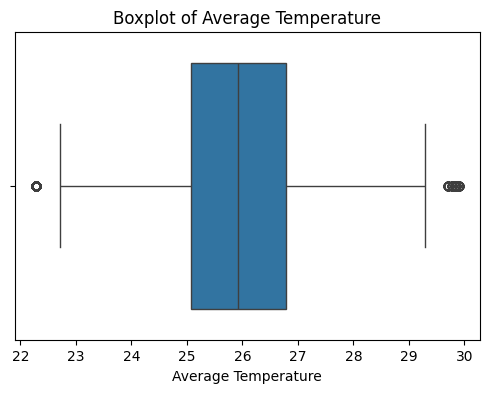

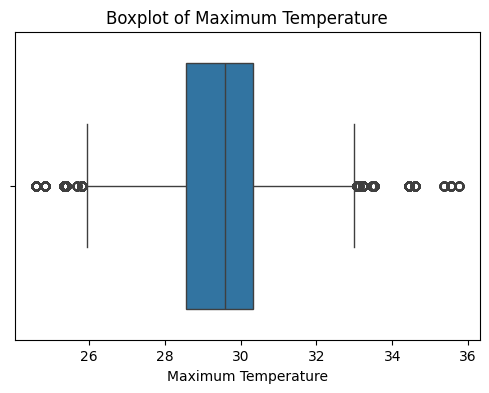

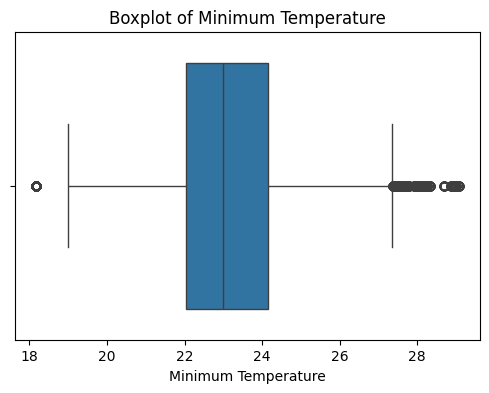

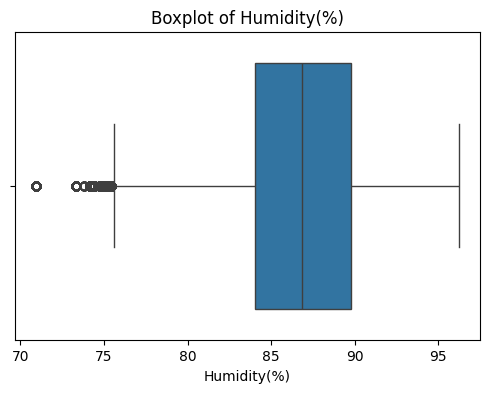

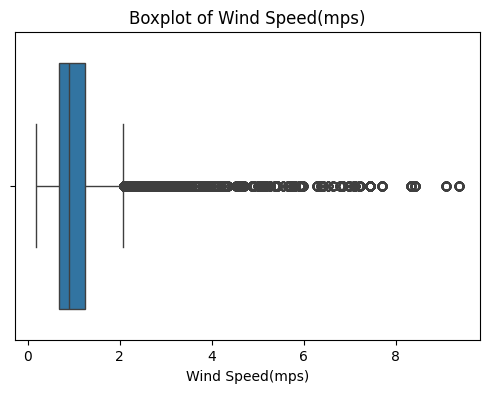

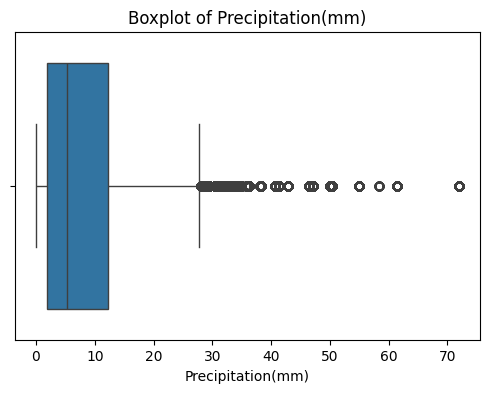

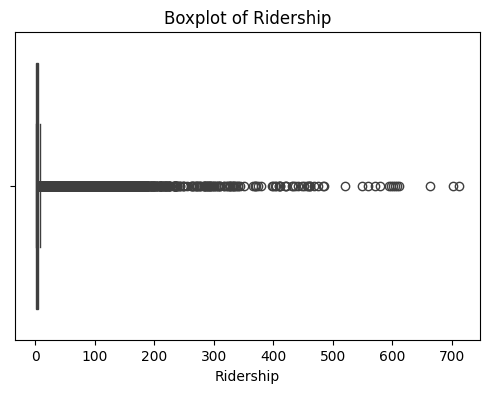

In [ ]:
# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Based on the observation, although these values are statistically outliers but they are not abnormal in Malaysia. The ranges of these values **doesn't show sharp spikes or drops** while still consistent with natural variations expected. Therefore, they are not considered extreme in a practical sense and do not indicate data entry errors or anomalies. Instead, these outliers are rare but valid observations. Hence, no outlier are removed to avoid loss of informative cases.

In [ ]:
# Ourliers value
for col in numeric_cols[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].unique()
    outliers = sorted(set(round(x, 2) for x in outliers.tolist()))

    if outliers:
        print(f"\nOutliers in '{col}':")
        print(outliers)


Outliers in 'Average Temperature':
[22.28, 29.71, 29.78, 29.84, 29.85, 29.9]

Outliers in 'Maximum Temperature':
[24.61, 24.86, 25.35, 25.41, 25.68, 25.81, 33.06, 33.07, 33.09, 33.13, 33.23, 33.46, 33.51, 34.43, 34.59, 35.35, 35.55, 35.75]

Outliers in 'Minimum Temperature':
[18.17, 27.38, 27.39, 27.4, 27.41, 27.45, 27.46, 27.47, 27.48, 27.49, 27.52, 27.53, 27.61, 27.64, 27.66, 27.7, 27.73, 27.76, 27.8, 27.92, 27.97, 28.0, 28.03, 28.05, 28.12, 28.13, 28.15, 28.16, 28.18, 28.2, 28.23, 28.24, 28.25, 28.32, 28.33, 28.68, 28.88, 28.91, 28.96, 29.01, 29.07]

Outliers in 'Humidity(%)':
[70.93, 73.35, 73.82, 74.14, 74.25, 74.38, 74.71, 74.91, 75.02, 75.03, 75.14, 75.15, 75.23, 75.32, 75.42, 75.44]

Outliers in 'Wind Speed(mps)':
[2.09, 2.1, 2.11, 2.12, 2.13, 2.15, 2.16, 2.17, 2.19, 2.2, 2.21, 2.22, 2.24, 2.25, 2.26, 2.3, 2.31, 2.33, 2.35, 2.36, 2.37, 2.38, 2.39, 2.4, 2.42, 2.43, 2.45, 2.46, 2.47, 2.5, 2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59, 2.6, 2.61, 2.62, 2.63, 2.64, 2.65, 2.68, 2.69, 2.

**2.6 Transformation**

**2.6.1 Datetime Construction & Time-Series Indexing**

In [ ]:
# Convert Date and Time to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

# Combine and sort by Datetime for time-series handling
df['Datetime'] = pd.to_datetime(df['Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time'].dt.strftime('%H:%M:%S'))
df = df.sort_values(by='Datetime').reset_index(drop=True)

**2.6.2 Feature Engineering (including Lagged Features)**

In [ ]:
# Create a unique identifier for each origin-destination pair for lagged features
df['OD_Pair'] = df['Origin'] + '_' + df['Destination']

# Create lagged ridership features
# We will group by OD_Pair and then apply the shift
df['Ridership_Lag1'] = df.groupby('OD_Pair')['Ridership'].shift(1)
df['Ridership_Lag24'] = df.groupby('OD_Pair')['Ridership'].shift(24) # Assuming hourly data and daily pattern

# Handle NaNs created by lagging
# For simplicity, we'll drop rows with NaNs created by lagging for now.
df.dropna(subset=['Ridership_Lag1', 'Ridership_Lag24'], inplace=True)

# Extract time-based features
df['Hour'] = df['Time'].dt.hour
df['Weekday'] = df['Date'].dt.weekday

# Drop original Date, Time, Datetime and OD_Pair after feature engineering
df = df.drop(columns=['Date', 'Time', 'Datetime', 'OD_Pair'])

# Convert boolean features to integers
bool_cols = ["Is Holiday", "Is Weekend", "Is Rush Hour"]
for col in bool_cols:
    df[col] = df[col].astype(int)

**2.6.3 Data Splitting (Temporal Split)**

In [ ]:
# Split into train and test (temporal split)
train_size = int(len(df) * 0.8)
train_df = df[:train_size].copy()
test_df = df[train_size:].copy()

# Separate features and target
X_train = train_df.drop("Ridership", axis=1)
y_train = train_df["Ridership"]
X_test = test_df.drop("Ridership", axis=1)
y_test = test_df["Ridership"]

**2.6.4 Scaling and Encoding**

We are using min-max normalization instead of Z-score normalization because all the numerical features are not normally distributed showed by the results of EDA.

In [ ]:
# Identify categorical and numerical columns
cat_cols = ["Origin", "Destination"]
num_cols = [col for col in X_train.columns if col not in cat_cols]

# One-hot encode categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform training data
encoded_train_array = encoder.fit_transform(X_train[cat_cols])
encoded_test_array = encoder.transform(X_test[cat_cols])

encoded_train_df = pd.DataFrame(encoded_train_array,
                                columns=encoder.get_feature_names_out(cat_cols),
                                index=X_train.index)

encoded_test_df = pd.DataFrame(encoded_test_array,
                               columns=encoder.get_feature_names_out(cat_cols),
                               index=X_test.index)

# Drop original categorical columns and join encoded ones
X_train = X_train.drop(columns=cat_cols).join(encoded_train_df)
X_test = X_test.drop(columns=cat_cols).join(encoded_test_df)

# Min-max normalize numeric features
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## **3.0 EDA**

**3.1 Find the dimension of the dataset**

Our dataset have 775199 rows and 15 columns.

In [ ]:
df.shape

(775199, 15)

**3.2 Find the data types of each feature**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775199 entries, 0 to 775198
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 775199 non-null  object 
 1   Time                 775199 non-null  object 
 2   Origin               775199 non-null  object 
 3   Destination          775199 non-null  object 
 4   Is Holiday           775199 non-null  bool   
 5   Day Of Week          775199 non-null  int64  
 6   Is Weekend           775199 non-null  bool   
 7   Is Rush Hour         775199 non-null  bool   
 8   Average Temperature  775199 non-null  float64
 9   Maximum Temperature  775199 non-null  float64
 10  Minimum Temperature  775199 non-null  float64
 11  Humidity(%)          775199 non-null  float64
 12  Wind Speed(mps)      775199 non-null  float64
 13  Precipitation(mm)    775199 non-null  float64
 14  Ridership            775199 non-null  int64  
dtypes: bool(3), float

**3.3 Look at the feature names**

In [ ]:
list(df.columns)

['Date',
 'Time',
 'Origin',
 'Destination',
 'Is Holiday',
 'Day Of Week',
 'Is Weekend',
 'Is Rush Hour',
 'Average Temperature',
 'Maximum Temperature',
 'Minimum Temperature',
 'Humidity(%)',
 'Wind Speed(mps)',
 'Precipitation(mm)',
 'Ridership']

**3.4 Row of Highest Ridership**

📌Interpretation:

A **warm, humid, and sunny day** that is a calm weather day with little wind movement.
Cloudy or overcast skies might be present, given the humidity and precipitation, but no storm or severe weather is indicated. Since it is holiday and in the afternoon 1 p.m., so it is the reason why we have the largest ridership.

In [ ]:
# Find maximum value of ridership with its features
max_ridership_value = df['Ridership'].max()
rows_with_highest_ridership = df[df['Ridership'] == max_ridership_value]
display(rows_with_highest_ridership)

,Date,Time,Origin,Destination,Is Holiday,Day Of Week,Is Weekend,Is Rush Hour,Average Temperature,Maximum Temperature,Minimum Temperature,Humidity(%),Wind Speed(mps),Precipitation(mm),Ridership
270827,2025-02-11,13:00,Batu Caves,KL Sentral,True,1,False,False,25.65,30.93,20.98,80.92,0.7,0.0,712


**3.5 Significant Difference for 'Is Weekend' feature (Univariate)**

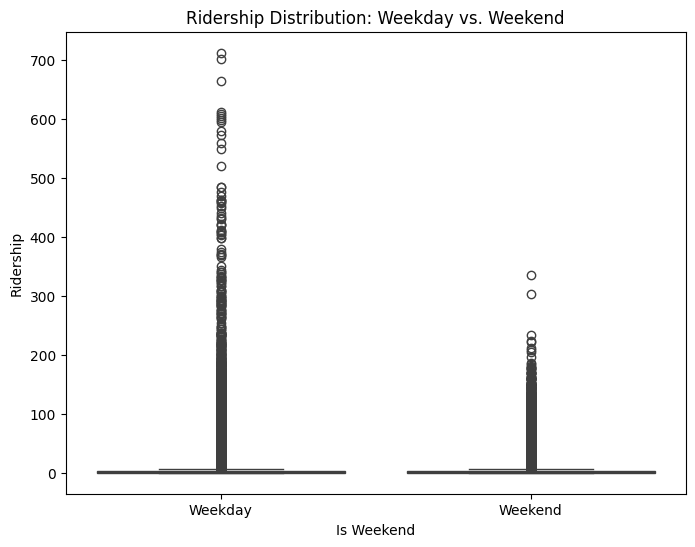

In [ ]:
# Create a box plot to compare ridership distributions
plt.figure(figsize=(8, 6))
sns.boxplot(x='Is Weekend', y='Ridership', data=df)
plt.title('Ridership Distribution: Weekday vs. Weekend')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

**3.6 Ridership change throughout the hours of the day (Bivariate)?**

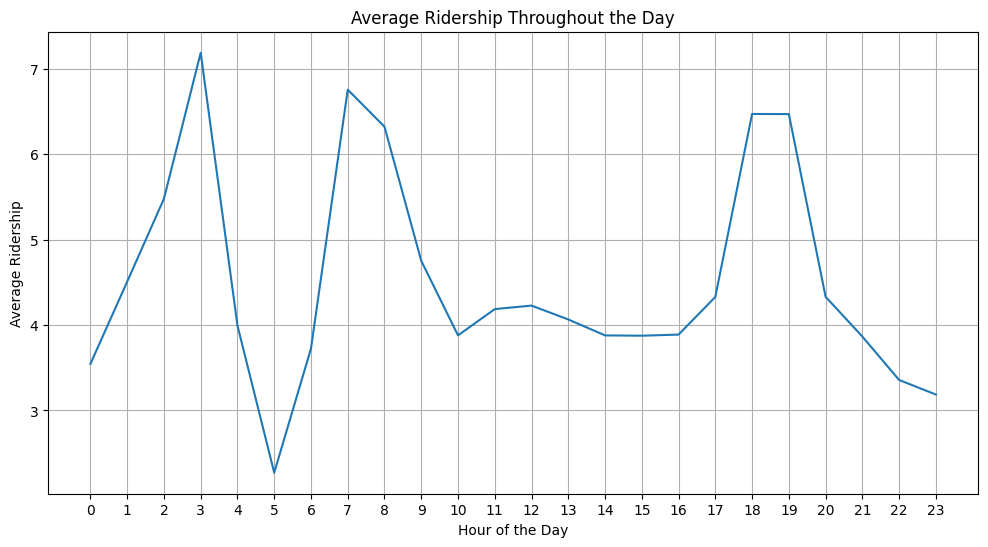

In [ ]:
df_eda = df.copy()
# Ensure Date and Time are datetime objects
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
df_eda['Time'] = pd.to_datetime(df_eda['Time'], format='%H:%M')

# Combine Date and Time into a datetime column for sorting
df_eda['Datetime'] = pd.to_datetime(df_eda['Date'].astype(str) + ' ' + df_eda['Time'].dt.strftime('%H:%M'))
df_eda = df_eda.sort_values(by='Datetime').reset_index(drop=True)
df_eda = df_eda.drop(columns=['Datetime'])

# Extract hour from Time column
df_eda['Hour'] = df_eda['Time'].dt.hour
df_eda['Weekday'] = df_eda['Date'].dt.weekday

average_ridership_by_hour = df_eda.groupby('Hour')['Ridership'].mean()

# Plot the average ridership by hour
plt.figure(figsize=(12, 6))
average_ridership_by_hour.plot(kind='line')
plt.title('Average Ridership Throughout the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Ridership')
plt.xticks(range(24))
plt.grid(True)
plt.show()

**3.6 Store the numeric & target features names in separate variables**

In [ ]:
df_processed = df.copy()
binary_features = ['Is Holiday', 'Is Weekend', 'Is Rush Hour']
df_processed[binary_features] = df_processed[binary_features].astype(int)

num_cols = ['Is Weekend','Is Holiday','Is Rush Hour','Day Of Week','Average Temperature', 'Maximum Temperature', 'Minimum Temperature','Humidity(%)', 'Wind Speed(mps)', 'Precipitation(mm)']
date = 'Date'
target_feature = 'Ridership'

**3.7 Visualization of numerical features**

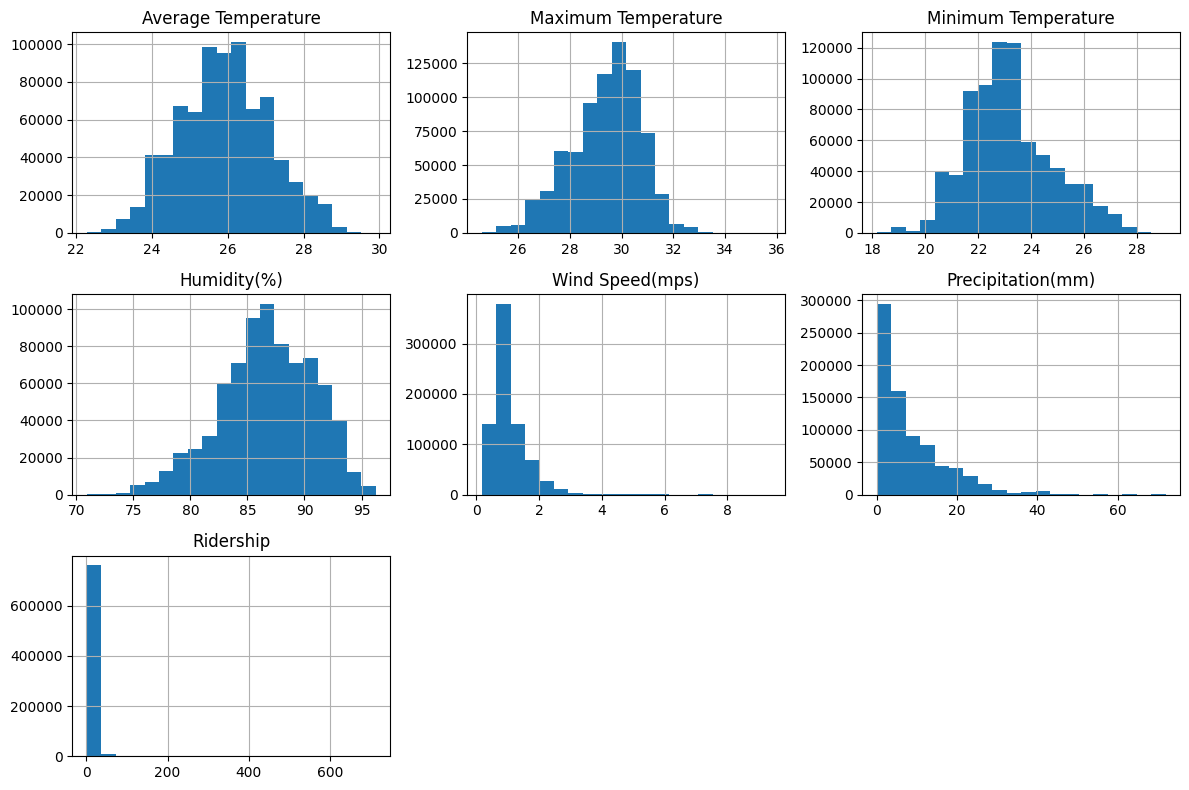

In [ ]:
#Histogram
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

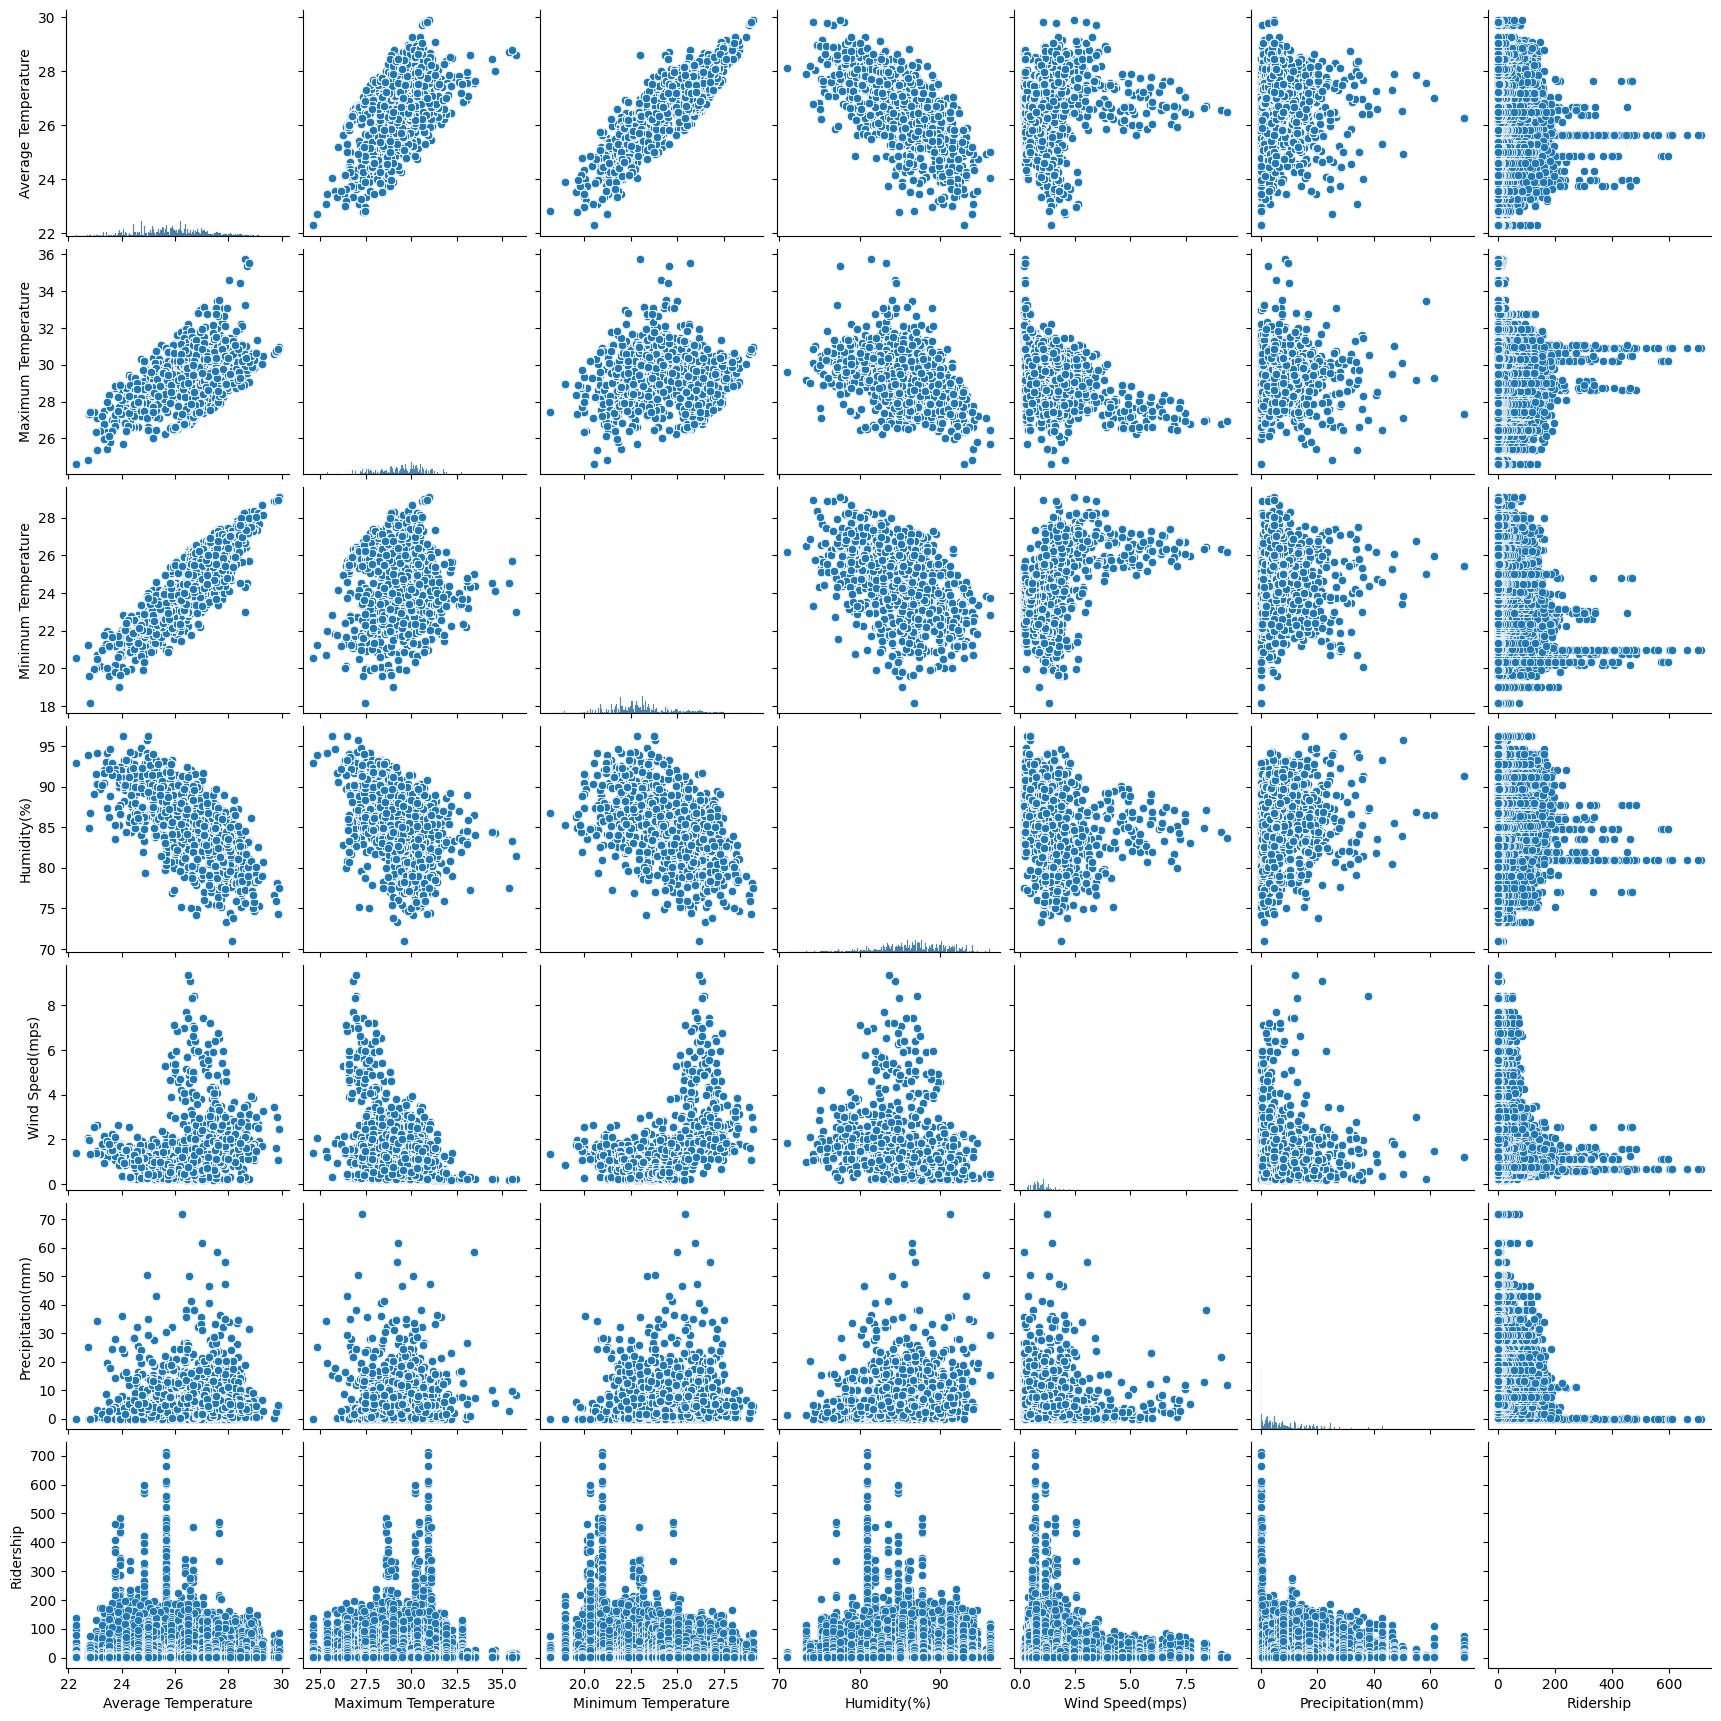

In [ ]:
#Scatter plot
sns.pairplot(df[numeric_cols])
plt.show()

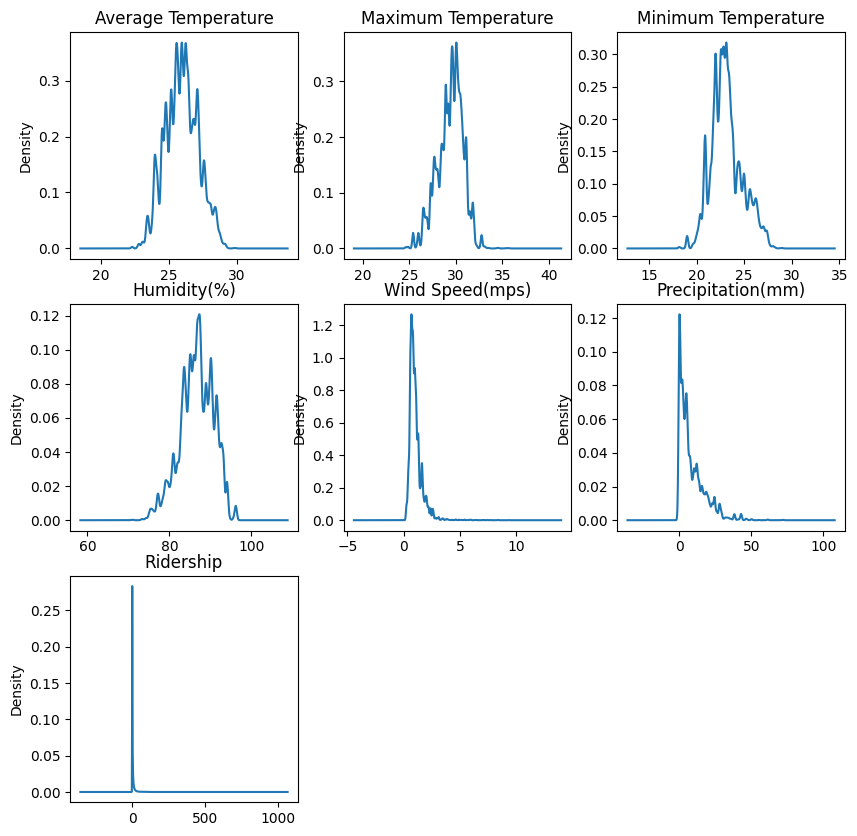

In [ ]:
# Density plot
fig,ax = plt.subplots(3,3,figsize=(10,10))
row = col = 0
for n,i in enumerate(numeric_cols):
    if (n%3 == 0) & (n > 0):
        row += 1
        col = 0
    df[i].plot(kind="kde",ax=ax[row,col])
    ax[row,col].set_title(i)
    col += 1

for i in range(len(numeric_cols), 9):
    fig.delaxes(ax.flatten()[i])

**3.8 Looking at the distributions of the numeric features by normaltest**

In [ ]:
# D’Agostino and Pearson’s normality test
from scipy.stats import normaltest

for i in numeric_cols:
    print(f'{i}: {"Not Gaussian" if normaltest(df[i].values,)[1]<0.05 else "Gaussian"}  {normaltest(df[i].values)}')

Average Temperature: Not Gaussian  NormaltestResult(statistic=np.float64(127993.756335488), pvalue=np.float64(0.0))
Maximum Temperature: Not Gaussian  NormaltestResult(statistic=np.float64(185639.6838511665), pvalue=np.float64(0.0))
Minimum Temperature: Not Gaussian  NormaltestResult(statistic=np.float64(177521.7361952322), pvalue=np.float64(0.0))
Humidity(%): Not Gaussian  NormaltestResult(statistic=np.float64(236445.61746069585), pvalue=np.float64(0.0))
Wind Speed(mps): Not Gaussian  NormaltestResult(statistic=np.float64(628991.3167269486), pvalue=np.float64(0.0))
Precipitation(mm): Not Gaussian  NormaltestResult(statistic=np.float64(264145.14123820834), pvalue=np.float64(0.0))
Ridership: Not Gaussian  NormaltestResult(statistic=np.float64(1375360.411703436), pvalue=np.float64(0.0))


⚠️⚠️⚠️ All p-values are exactly **0.0**. This means **none** of these features follow a **Gaussian (normal) distribution**.

In [ ]:
#Kolmogorov-Smirnov (KS) test
from scipy.stats import kstest, norm

results_ks = {}
for col in numeric_cols:
    data = df[col].dropna()
    data_std = (data - data.mean()) / data.std()
    stat, p = kstest(data_std, 'norm')
    results_ks[col] = {'statistic': stat, 'p_value': p}
ks_df = pd.DataFrame(results_ks).T
print(ks_df)

                     statistic  p_value
Average Temperature   0.440545      0.0
Maximum Temperature   0.382358      0.0
Minimum Temperature   0.454551      0.0
Humidity(%)           0.467732      0.0
Wind Speed(mps)       0.368911      0.0
Precipitation(mm)     0.413057      0.0
Ridership             0.363878      0.0


**3.9 Looking at the target (Ridership) feature's statistics**

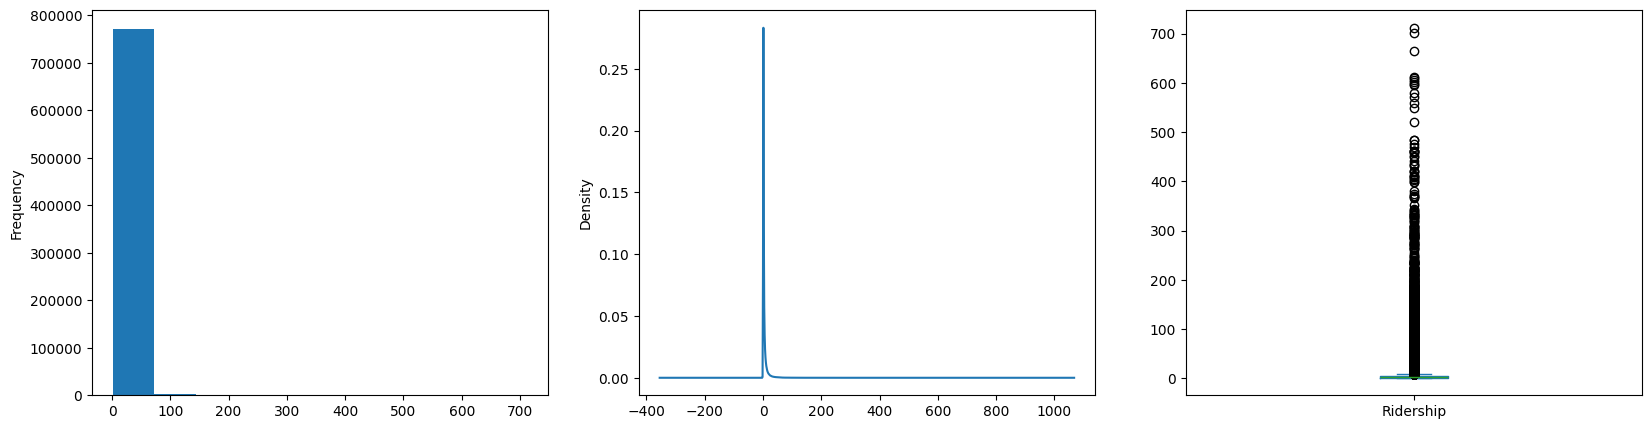

Ridership: Not GaussianNormaltestResult(statistic=np.float64(1375360.411703437), pvalue=np.float64(0.0))


In [ ]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
df[target_feature].plot(kind="hist",ax=ax[0])
df[target_feature].plot(kind="kde",ax=ax[1])
df[target_feature].plot(kind="box",ax=ax[2])
plt.show()
print(f'{target_feature}: {"Not Gaussian" if normaltest(df[target_feature].values,)[1]<0.05 else "Gaussian"}{normaltest(df[target_feature].values)}')

**3.10 Looking at the relationship between numeric and target features**

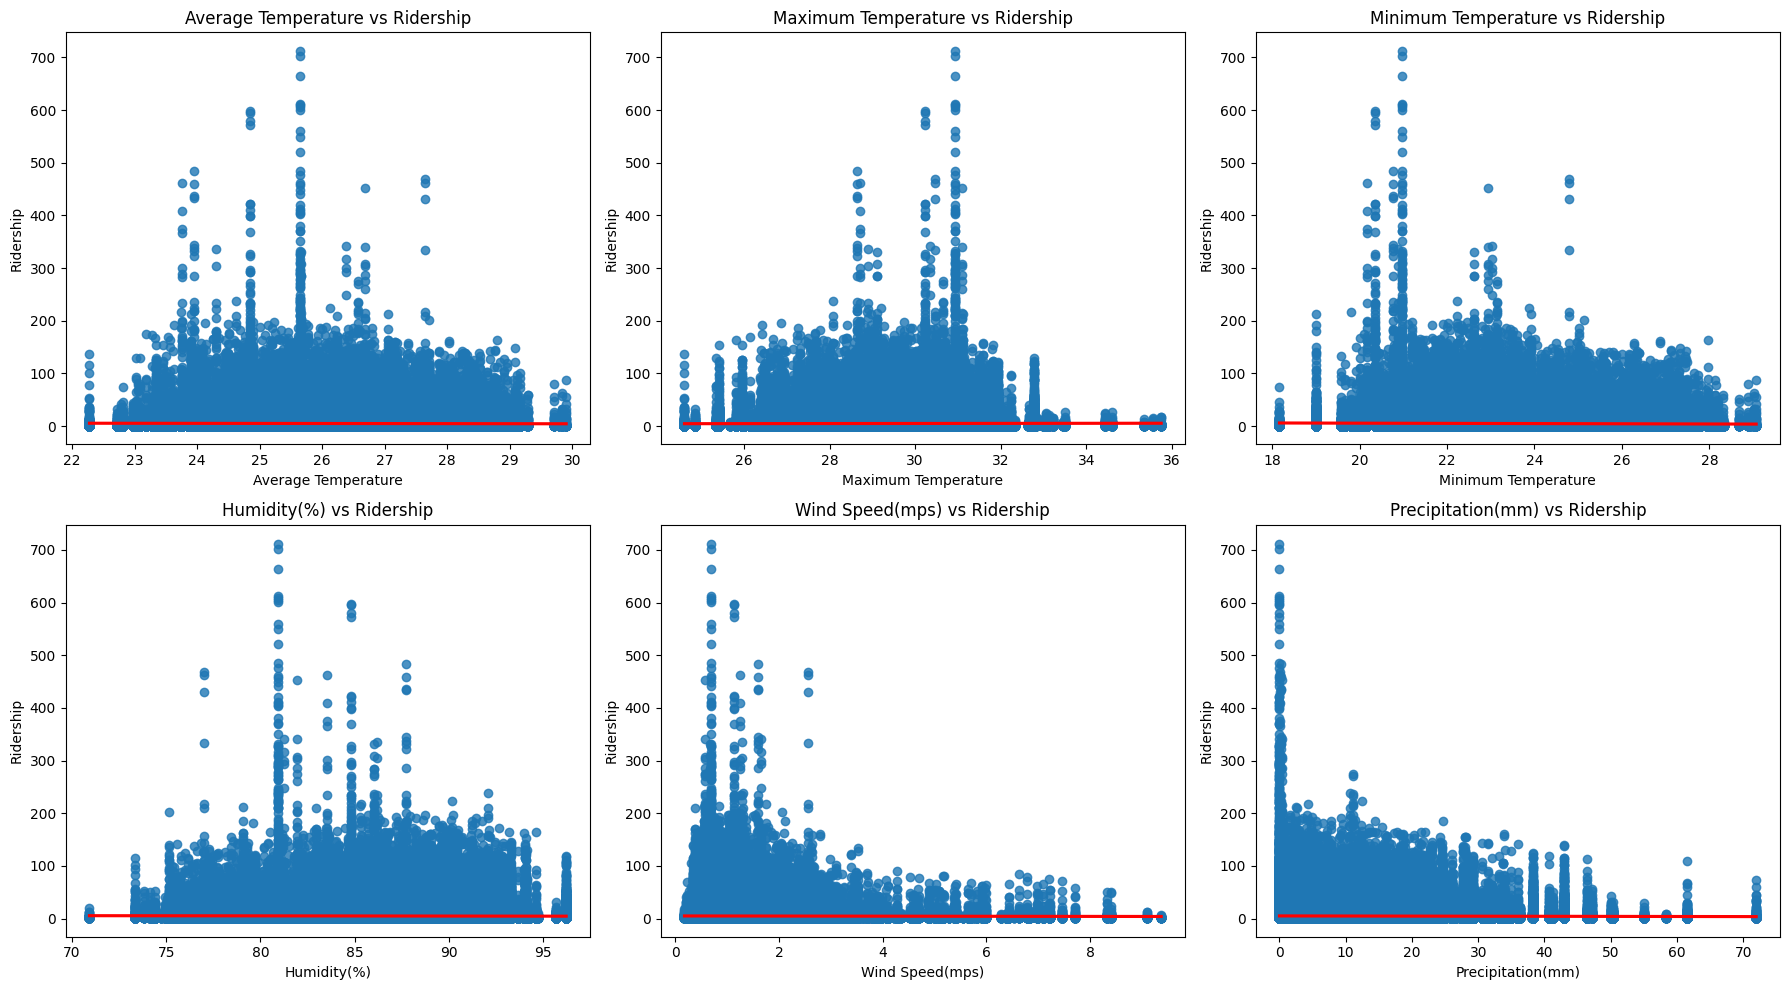

In [ ]:
#Regression plot
numerical_features = ['Average Temperature', 'Maximum Temperature', 'Minimum Temperature','Humidity(%)', 'Wind Speed(mps)', 'Precipitation(mm)']

# Create subplots
fig, ax = plt.subplots(2, 3, figsize=(18, 10))  # 6 features → 2 rows × 3 columns
ax = ax.flatten()

# Plot regression plots
for i, feature in enumerate(numerical_features):
    sns.regplot(x=feature, y="Ridership",data=df,ax=ax[i],ci=False,line_kws={'color': 'red'}
    )
    ax[i].set_title(f"{feature} vs Ridership")

# Adjust layout
plt.tight_layout()
plt.show()

**b) Pearson' correlation (P)**

Pearson’ correlation coefficient measures **linear relationship** between two variables.

In our dataset, the Pearson’ correlation coefficient shows that **‘Is Weekend’，‘Day Of Week’，‘Average Tempperature’, ‘Maximum Tempperature’, ‘Minimum Tempperature’, ‘Wind Speed’ and ‘Precipitation’** are **negatively correlated** with the target and the linear relationship is weak. Whereas, **‘Humidity’，‘Is Rush Hour’ and ‘Is Holiday’** are **positively correlated** with the target but the linear relationship is also weak.


<Axes: >

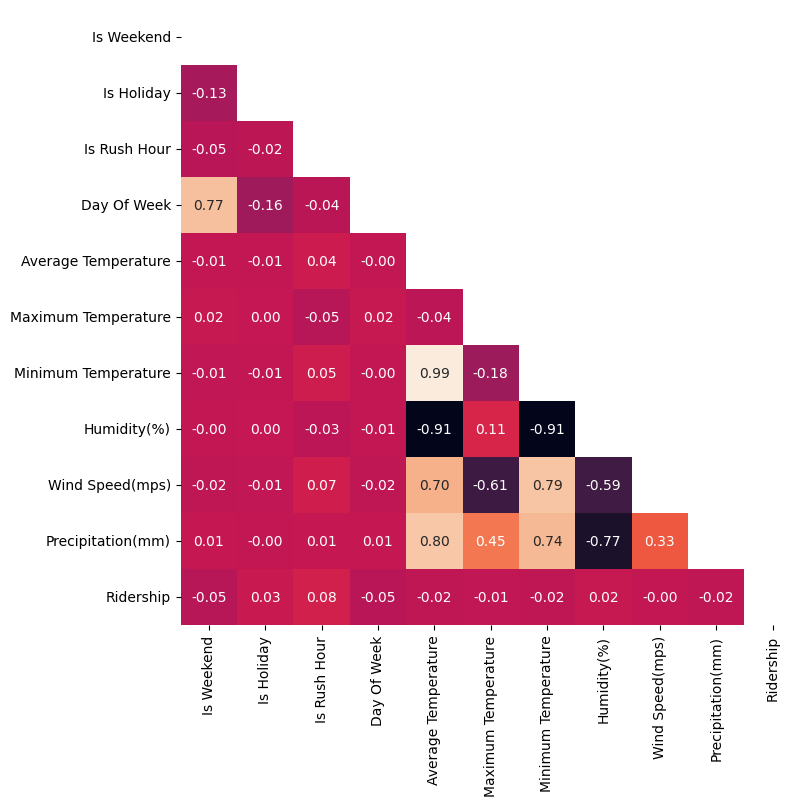

In [ ]:
#num_cols = ['Is Weekend','Is Holiday','Is Rush Hour','Day Of Week','Average Temperature', 'Maximum Temperature', 'Minimum Temperature','Humidity(%)', 'Wind Speed(mps)', 'Precipitation(mm)','Ridership']
fig = plt.figure(figsize=(8,8))
sns.heatmap(df_processed[num_cols + ['Ridership']].corr(method='pearson'),annot=True,fmt='.2f',
            mask=np.triu(df_processed[num_cols + ['Ridership']].corr(method='pearson')),cbar=False)

**c) Spearman's Rank Correlation (R)**

Spearman's Rank Correlation measures the **monotonic relationship** between two variables whether they increase or decrease together, but not necessarily linearly. In our dataset, **‘Is Weekend’，‘Day Of Week’，‘Average Tempperature’, ‘Minimum Tempperature’, ‘Wind Speed’ and ‘Precipitation’** shows a **weak negative relationship** with 'Ridership' compare to the relationship between **'Humidity', ‘Maximum Tempperature’,‘Is Rush Hour’ and ‘Is Holiday’** with 'Ridership' that shows a **weak positive relationship**.

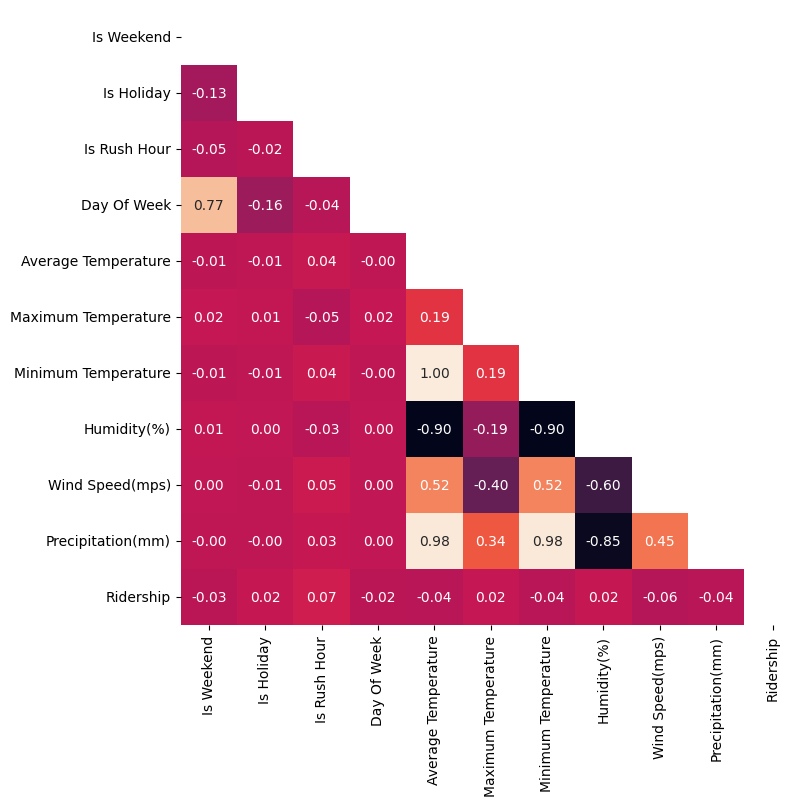

In [ ]:
fig = plt.figure(figsize=(8, 8))
spearman_corr = df_processed[num_cols + ['Ridership']].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, fmt=".2f",
            mask=np.triu(spearman_corr), cbar=False)
plt.show()

**d) Kendall's Rank Correlation (τ)**

Kendall’s correlation coefficient values is to find out **ordinal association** between two variables (less sensitive to outliers). From Kendall’s correlation coefficient, it shows the same results of relationship as Spearman's Rank Correlation.


<Axes: >

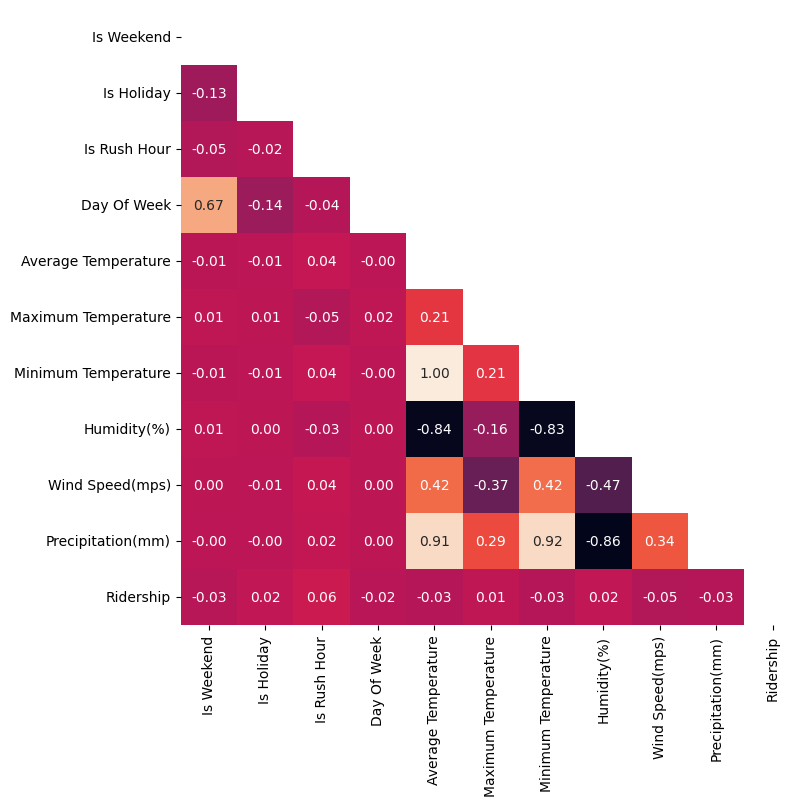

In [ ]:
fig = plt.figure(figsize=(8,8))
sns.heatmap(df_processed[num_cols + ['Ridership']].corr(method='kendall'),annot=True,
            fmt='.2f',mask=np.triu(df_processed[num_cols + ['Ridership']].corr(method='pearson')),cbar=False)


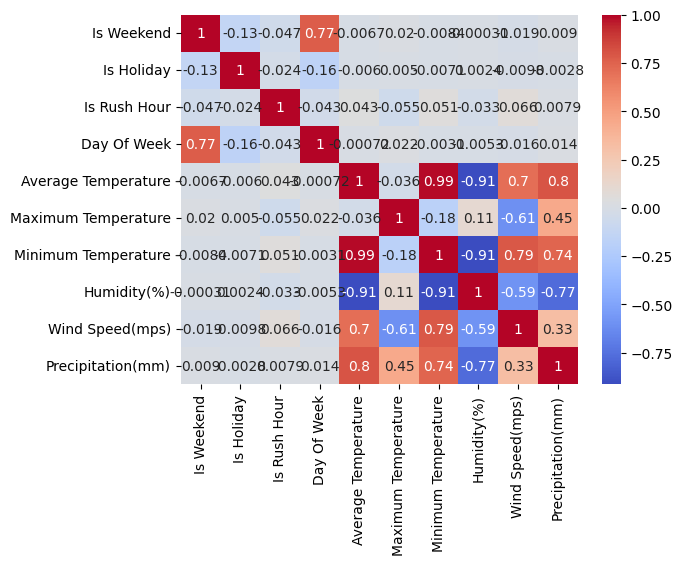

In [ ]:
#Heatmap
correlation_matrix = df_processed[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

## **4.0 Model Selection & Model Training**

**4.1 Model Selection**

We select and prepare various regression models to forecast the hourly ridership.

Based on problem objective and the time-series nature of the data, we will evaluate several models.

We will also use time-series cross-validation ('TimeSeriesSplit') during hyperparameter tuning to ensure robust evaluation that respects the temporal order of the data.


1. **LightGBM Regressor:** A gradient boosting framework that uses tree-based learning algorithms. It's known for its speed and efficiency.
2. **XGBoost Regressor:** Another popular and powerful boosting algorithm.
3. CatBoost Regressor: A gradient boosting library with support for categorical features.
4. **HistGradientBoosting Regressor:** A fast gradient boosting model implemented in scikit-learn.
5. **Decision Tree Regressor:** A basic tree-based model.
6. **Random Forest Regressor:** An ensemble method training data and evaluate their performance on the test set using metrics like *Mean Square Error (MSE), Root Mean Square Error (RMSE), and R-square (R²)*.



**4.2 Model Training and Evaluation**

We implement the training and evaluation of the selected models.

- Load the preprocessed data.
- Apply feature engineering, including creating lagged ridership features.
- Perform a temporal split of the data into training and testing sets.
- Scale numerical features and one-hot encode categorical features.
- Train each selected model on the training data.
- Predict ridership on the test data.
- Evaluate the performance of each model using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared (R²), and Accuracy metrics.
- Visualize the results to compare model performance.

**4.2.1 Import Libraries**

In [ ]:
# Install necessary libraries
!pip install --quiet xgboost catboost lightgbm

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectKBest, f_regression # Import for feature selection

# Set seaborn style
sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00


**4.2.2 Feature Selection**

In [ ]:
# Select the top k features
k = 50
selector = SelectKBest(score_func=f_regression, k=k)

# Fit on training data and transform both training and testing data
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get the names of the selected features
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X_train.columns[selected_feature_indices]
print("\nSelected features after SelectKBest:")
print(selected_feature_names)


Selected features after SelectKBest:
Index(['Is Holiday', 'Day Of Week', 'Is Weekend', 'Is Rush Hour',
       'Ridership_Lag1', 'Ridership_Lag24', 'Weekday', 'Origin_Bank Negara',
       'Origin_Batu Caves', 'Origin_KL Sentral', 'Origin_Kajang 2',
       'Origin_Kepong Sentral', 'Origin_Kuala Kubu Bharu',
       'Origin_Kuala Lumpur', 'Origin_Labu', 'Origin_Pulau Sebang (Tampin)',
       'Origin_Putra', 'Origin_Rembau', 'Origin_Salak Selatan',
       'Origin_Sentul', 'Origin_Seputeh', 'Origin_Serdang', 'Origin_Seremban',
       'Origin_Subang Jaya', 'Origin_Sungai Gadut', 'Origin_Taman Wahyu',
       'Destination_Bank Negara', 'Destination_Batu Caves',
       'Destination_Batu Tiga', 'Destination_KL Sentral', 'Destination_Kajang',
       'Destination_Kajang 2', 'Destination_Kepong Sentral',
       'Destination_Kuala Kubu Bharu', 'Destination_Kuala Lumpur',
       'Destination_Labu', 'Destination_Pantai Dalam',
       'Destination_Pulau Sebang (Tampin)', 'Destination_Putra',
       'De

**4.2.3 Model Training (with potential Hyperparameter Tuning)**

In [ ]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# 1. LGBM
lgbm_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, -1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
lgbm_model = RandomizedSearchCV(LGBMRegressor(random_state=42), lgbm_param_grid,
                                n_iter=20, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.200318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 573982, number of used features: 129
[LightGBM] [Info] Start training from score 5.104409


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=LGBMRegressor(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, -1],
                                        'n_estimators': [100, 300, 500],
                                        'num_leaves': [15, 31, 63],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_mean_squared_error')

In [ ]:
# 2. XGBoost
xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_model = RandomizedSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'),
                               xgb_param_grid, n_iter=20, cv=tscv,
                               scoring='neg_mean_squared_error', n_jobs=-1)
xgb_model.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=No...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 300, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_mean_squared_error')

In [ ]:
# 3. CatBoost
cat_param_grid = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7, 10],
    'l2_leaf_reg': [1, 3, 5, 7]
}
cat_model = RandomizedSearchCV(CatBoostRegressor(random_state=42, verbose=0),
                               cat_param_grid, n_iter=20, cv=tscv,
                               scoring='neg_mean_squared_error', n_jobs=-1)
cat_model.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=<catboost.core.CatBoostRegressor object at 0x7ab1337ae4d0>,
                   n_iter=20, n_jobs=-1,
                   param_distributions={'depth': [3, 5, 7, 10],
                                        'iterations': [100, 300, 500],
                                        'l2_leaf_reg': [1, 3, 5, 7],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   scoring='neg_mean_squared_error')

In [ ]:
# 4. HistGradientBoosting
hgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 300, 500],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [10, 20, 30]
}
hgb_model = RandomizedSearchCV(HistGradientBoostingRegressor(random_state=42),
                               hgb_param_grid, n_iter=20, cv=tscv,
                               scoring='neg_mean_squared_error', n_jobs=-1)
hgb_model.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=HistGradientBoostingRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [None, 5, 10],
                                        'max_iter': [100, 300, 500],
                                        'min_samples_leaf': [10, 20, 30]},
                   scoring='neg_mean_squared_error')

In [ ]:
# 5. Decision Tree
tree_param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'splitter': ['best', 'random'],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}
tree_model = RandomizedSearchCV(DecisionTreeRegressor(random_state=42),
                                      tree_param_grid, n_iter=10, cv=tscv,
                                      scoring='neg_mean_squared_error',n_jobs=-1)
tree_model.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
                                        'max_depth': [3, 5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 5, 10, 20],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   scoring='neg_mean_squared_error')

In [ ]:
# 6. Random Forest
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [18, 20, 22],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
rf_model = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                              rf_param_grid, n_iter=10,cv=tscv,
                              scoring='neg_mean_squared_error', n_jobs=-1)

rf_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
                   param_distributions={'max_depth': [18, 20, 22],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 300, 500]},
                   scoring='neg_mean_squared_error')

In [ ]:
# Initialize models
# We will use the models from original notebook and add the best estimators from initial tuning
models_to_evaluate = {
    'LightGBM': lgbm_model.best_estimator_,
    'XGBoost': xgb_model.best_estimator_,
    'CatBoost': cat_model.best_estimator_,
    'HistGradientBoosting': hgb_model.best_estimator_,
    'DecisionTree': tree_model.best_estimator_,
    'RandomForest': rf_model.best_estimator_
}

# Model training and evaluation
results = {}

for name, model in models_to_evaluate.items():
    print(f"\nTraining and evaluating {name}...")

    # Fit the model on the training data
    model.fit(X_train, y_train)

    # Predict on the test data
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    accuracy = r2 * 100

    results[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Accuracy (%)': accuracy}

    print(f"{name} Test MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, Accuracy: {accuracy:.2f}%")

# Summary of model performance
results_df = pd.DataFrame(results).T

# Format the Accuracy column to 2 decimal places
results_df['Accuracy (%)'] = results_df['Accuracy (%)'].round(2)

print("\nSummary of Model Performance on Test Set:")
print(results_df.round(4))


Training and evaluating LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.544280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 573982, number of used features: 129
[LightGBM] [Info] Start training from score 5.104409
LightGBM Test MSE: 22.3321, RMSE: 4.7257, R²: 0.7553, Accuracy: 75.53%

Training and evaluating XGBoost...
XGBoost Test MSE: 27.3816, RMSE: 5.2327, R²: 0.6999, Accuracy: 69.99%

Training and evaluating CatBoost...
CatBoost Test MSE: 24.7238, RMSE: 4.9723, R²: 0.7291, Accuracy: 72.91%

Training and evaluating HistGradientBoosting...
HistGradientBoosting Test MSE: 23.5588, RMSE: 4.8537, R²: 0.7418, Accuracy: 74.18%

Training and evaluating DecisionTree...
DecisionTree Test MSE: 33.0327, RMSE: 5.7474, R²: 0.6380, Accuracy: 63.80%

Traini

**4.2.4 Visualization of Results**

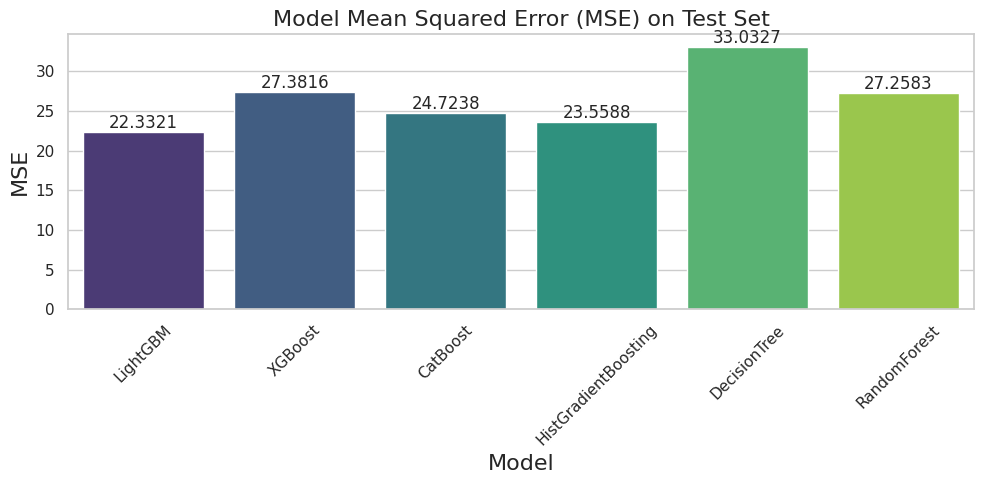

In [ ]:
# Plot MSE
plt.figure(figsize=(10, 5))
ax_mse = sns.barplot(x=results_df.index, y='MSE', data=results_df, palette='viridis', hue=results_df.index, legend=False)
plt.title("Model Mean Squared Error (MSE) on Test Set", fontsize=16)
plt.ylabel("MSE", fontsize=16)
plt.xlabel("Model",fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

# Add labels to bars
for container in ax_mse.containers:
    ax_mse.bar_label(container, fmt='%.4f')

plt.show()

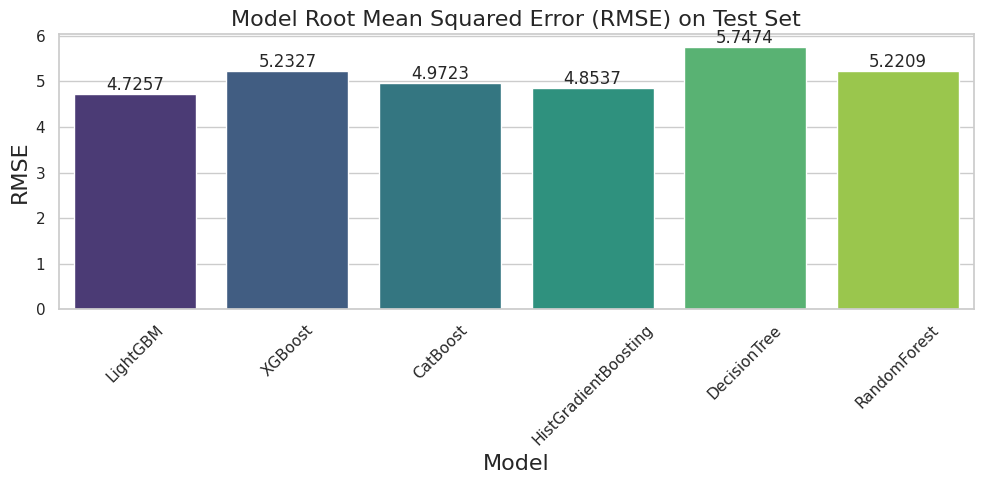

In [ ]:
# Plot RMSE
plt.figure(figsize=(10, 5))
ax_rmse = sns.barplot(x=results_df.index, y='RMSE', data=results_df, palette='viridis', hue=results_df.index, legend=False)
plt.title("Model Root Mean Squared Error (RMSE) on Test Set", fontsize=16)
plt.ylabel("RMSE", fontsize=16)
plt.xlabel("Model", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

# Add labels to bars
for container in ax_rmse.containers:
    ax_rmse.bar_label(container, fmt='%.4f')

plt.show()

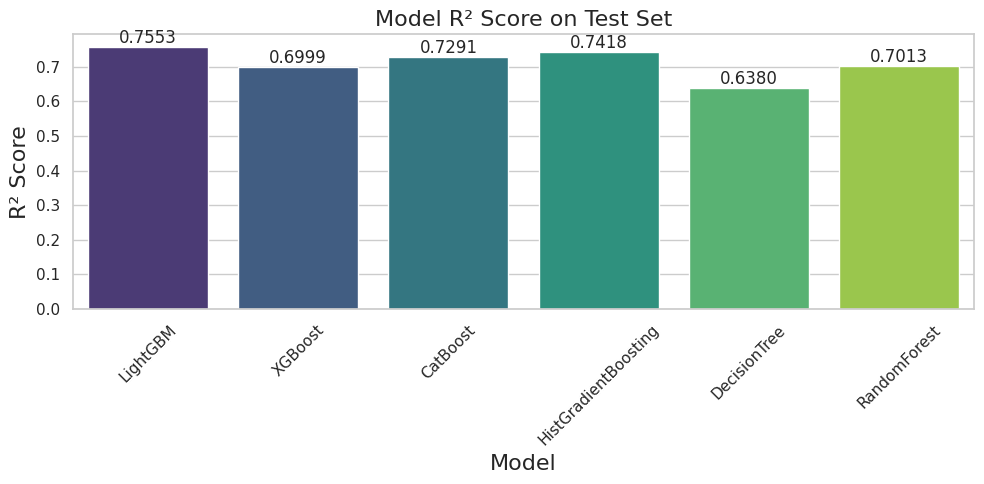

In [ ]:
# Plot R²
plt.figure(figsize=(10, 5))
ax_r2 = sns.barplot(x=results_df.index, y='R2', data=results_df, palette='viridis', hue=results_df.index, legend=False)
plt.title("Model R² Score on Test Set", fontsize=16)
plt.ylabel("R² Score", fontsize=16)
plt.xlabel("Model", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

# Add labels to bars
for container in ax_r2.containers:
    ax_r2.bar_label(container, fmt='%.4f')

plt.show()

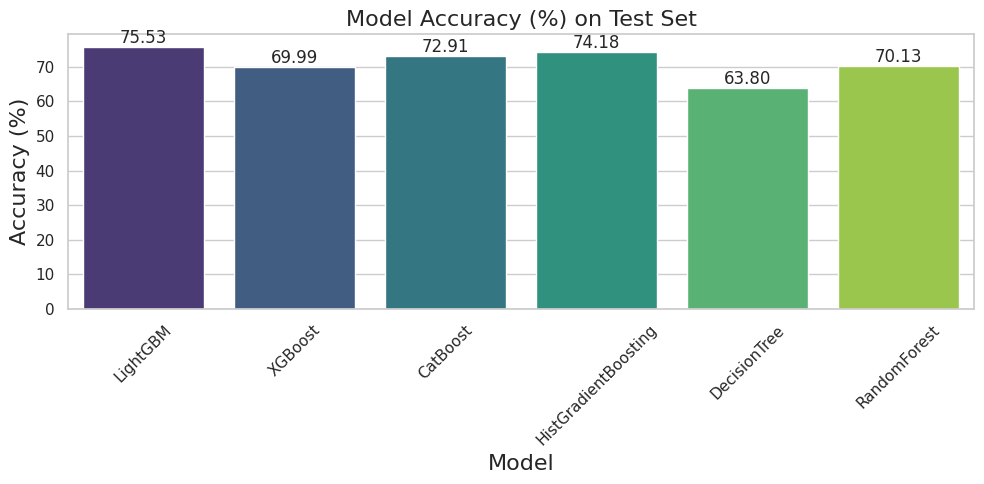

In [ ]:
# Plot Accuracy with labels
plt.figure(figsize=(10, 5))
ax_accuracy = sns.barplot(x=results_df.index, y='Accuracy (%)', data=results_df, palette='viridis', hue=results_df.index, legend=False)
plt.title("Model Accuracy (%) on Test Set", fontsize=16)
plt.ylabel("Accuracy (%)", fontsize=16)
plt.xlabel("Model", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()

# Add labels to bars
for container in ax_accuracy.containers:
    ax_accuracy.bar_label(container, fmt='%.2f')

plt.show()

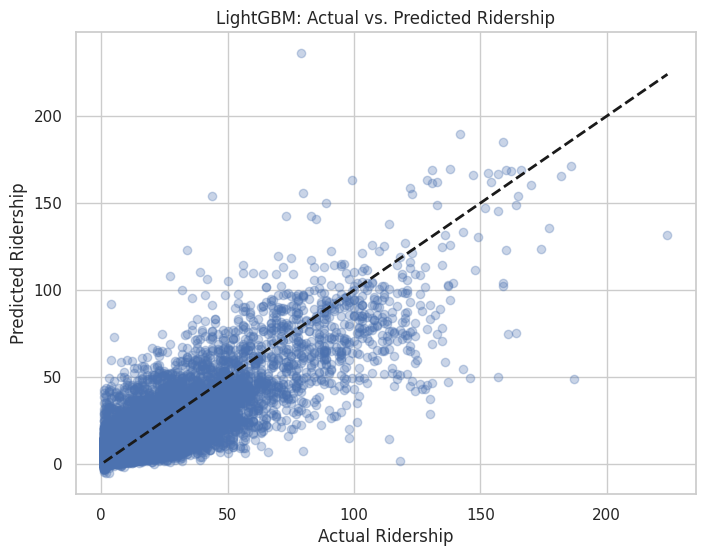

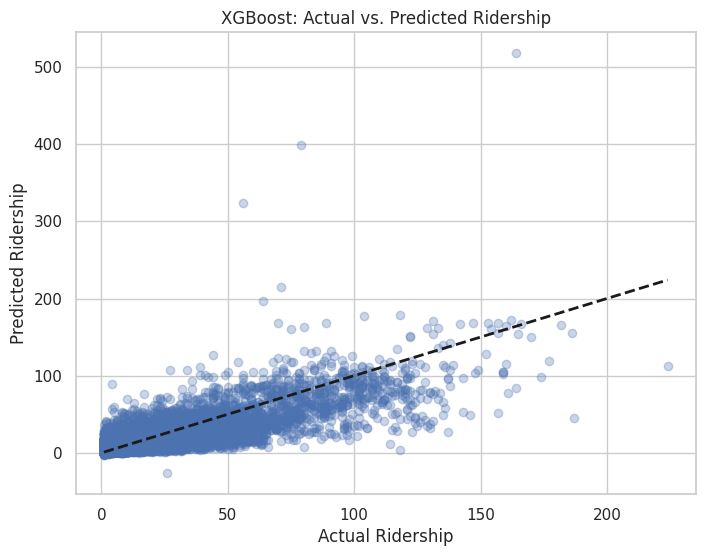

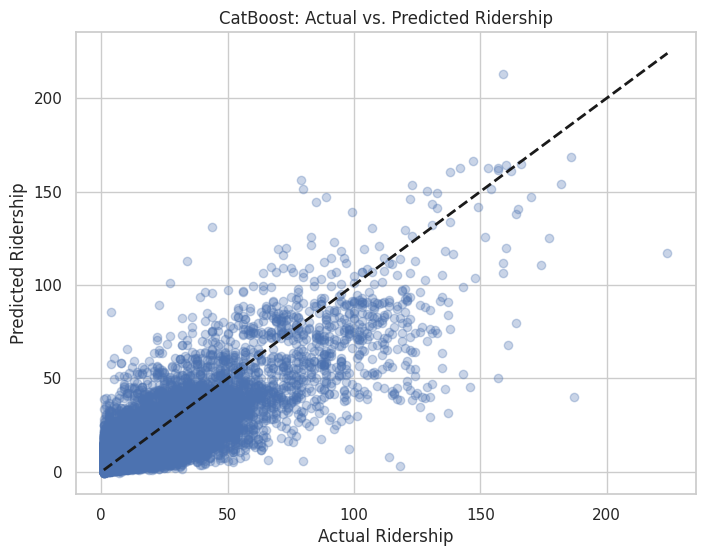

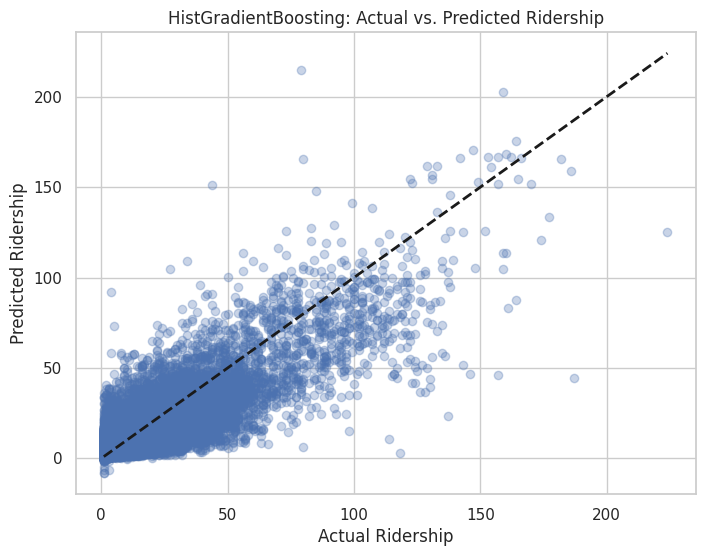

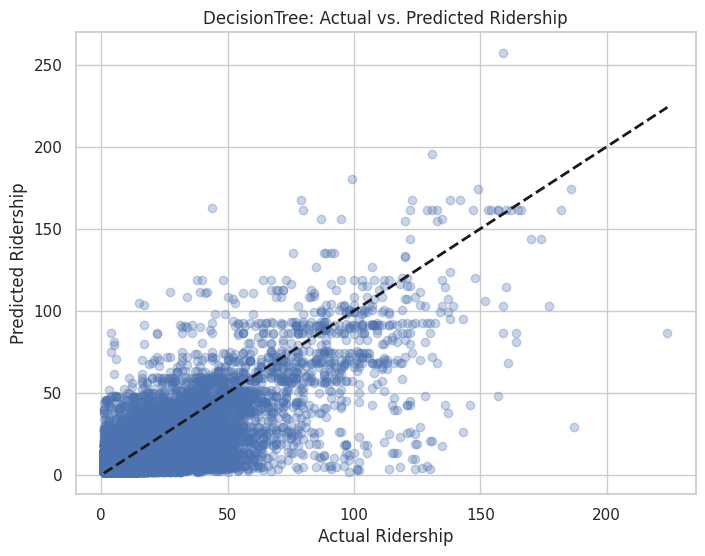

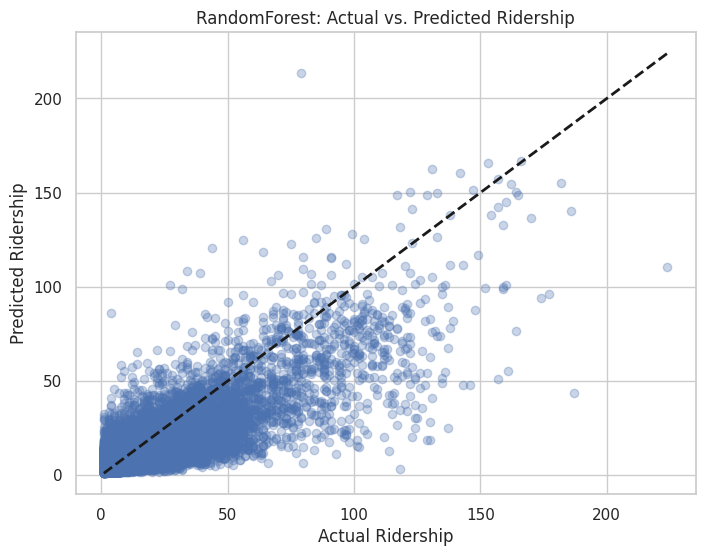

In [ ]:
# --- 6. Actual vs. Predicted Plots ---

for name, model in models_to_evaluate.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
    plt.xlabel("Actual Ridership")
    plt.ylabel("Predicted Ridership")
    plt.title(f"{name}: Actual vs. Predicted Ridership")
    plt.grid(True)
    plt.show()

**4.3 Best Model**

With this updated performance data, the **LightGBM** clearly demonstrates the best results across all the key metrics (MSE, RMSE, R², and Accuracy) after hyperparameter tuning using **RandomizedSearchCV**. It has the lowest error metrics and the highest R² and Accuracy, indicating it is the best performing model for forecasting ridership in this case.